# Human pilot: success versus user authority

Task 4 (bowl on top of the cabinet) by default; 10 trials per depth, FC at 2, 4, 6, 8, 10 and native FRS / FRS-RA at 1, 2, 4, 6, 8: 150 trials. Run `experiments/human_pilot.sh` first, then set `ROOT` below and Run All.

Depth means opposite things in the two methods: FC's `n_guided_steps` are denoising steps the operator *controls*, FRS's `n_reversal_steps` are steps the policy denoises *freely* after the reversal. The figures therefore use **user authority** — the operator's share of the 10-step denoising schedule, `n_guided / 10` for FC and `(10 − n_reversal) / 10` for the reversal arms (`analyze.authority`) — so 0 is the policy alone and 1 the whole schedule under the operator, whichever method. Keep each participant/session in its own output directory.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

REPO_ROOT = next(
    p
    for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "examples/pi05/libero_shared_autonomy/notebooks/analyze.py").exists()
)
sys.path.insert(0, str(REPO_ROOT / "examples/pi05/libero_shared_autonomy/notebooks"))
import analyze  # noqa: E402

plt.style.use(analyze.PAPER_STYLE)
ROOT = REPO_ROOT / "outputs/human_pilot/p01"
DEPTHS = {"FC": [2, 4, 6, 8, 10], "FRS": [1, 2, 4, 6, 8], "FRS-RA": [1, 2, 4, 6, 8]}
TRIALS_PER_CONDITION = 10

In [2]:
runs = analyze.find_runs(ROOT)
if not runs:
    raise FileNotFoundError(f"No trials in {ROOT}; collect data or change ROOT.")
trials, configs = analyze.load_runs(runs)
if trials.empty:
    raise ValueError("No completed trials yet.")
assert set(trials.operator) == {"human"}, "Select human data only."
assert trials.task_id.nunique() == 1, "Select one task for this pilot figure."
assert not trials.duplicated(["method", "depth", "pair_id"]).any(), "Duplicate trials: check for reruns."
expected = pd.MultiIndex.from_tuples(
    [(m, d) for m, ds in DEPTHS.items() for d in ds], names=["method", "depth"]
)
observed = trials.groupby(["method", "depth"]).size()
off_grid = observed.index.difference(expected)
if not off_grid.empty:
    # e.g. an aborted first attempt with another depth grid; kept out of the figures
    print("Off-grid blocks set aside (not in DEPTHS):")
    print(observed.loc[off_grid].rename("trials").to_string())
    trials = trials[~trials.set_index(["method", "depth"]).index.isin(off_grid)]
    observed = trials.groupby(["method", "depth"]).size()
counts = observed.reindex(expected, fill_value=0).rename("completed")
display(counts.unstack("depth"))
complete = bool((counts == TRIALS_PER_CONDITION).all())
if complete:
    pairs = [set(g.pair_id) for _, g in trials.groupby(["method", "depth"])]
    assert all(p == pairs[0] for p in pairs), "Conditions used different reset assignments."
else:
    print("PARTIAL DATA: the figures will be labeled partial.")
suffix = "" if complete else "_partial"
print(f"{len(trials)} completed trials: {trials.task_description.iloc[0]}")

depth,1.0,2.0,4.0,6.0,8.0,10.0
method,,,,,,
FC,NaN,10.0,10.0,10.0,10.0,10.0
FRS,10.0,10.0,10.0,10.0,10.0,NaN
FRS-RA,10.0,10.0,10.0,10.0,10.0,NaN


150 completed trials: put the bowl on top of the cabinet


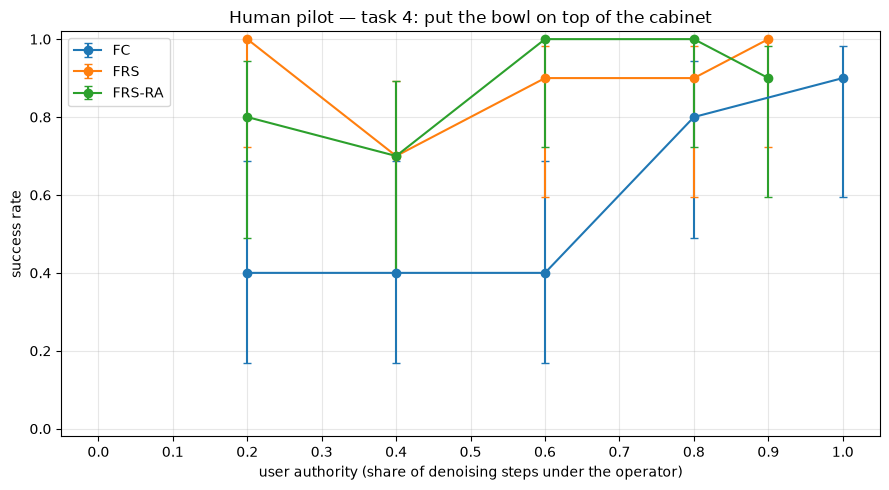

,method,authority,n,value,ci95_low,ci95_high
0,FC,0.2,10,0.4,0.168180,0.687326
1,FC,0.4,10,0.4,0.168180,0.687326
2,FC,0.6,10,0.4,0.168180,0.687326
3,FC,0.8,10,0.8,0.490162,0.943318
4,FC,1.0,10,0.9,0.595850,0.982124
5,FRS,0.2,10,1.0,0.722467,1.000000
6,FRS,0.4,10,0.7,0.396778,0.892209
7,FRS,0.6,10,0.9,0.595850,0.982124
8,FRS,0.8,10,0.9,0.595850,0.982124
9,FRS,0.9,10,1.0,0.722467,1.000000


Saved PNG, SVG, and CSV to /home/user/Projects/lerobot/outputs/human_pilot/p01/figures


In [3]:
task = int(trials.task_id.iloc[0])
title = f"Human pilot — task {task}: {trials.task_description.iloc[0]}"
if not complete:
    title += " (partial)"
export = ROOT / "figures"
export.mkdir(exist_ok=True)
fig, ax = plt.subplots(figsize=(8, 4.5))
curve = analyze.plot_metric(trials, ax, "success", title=title)
fig.tight_layout()
fig.savefig(export / f"success_vs_authority{suffix}.png", dpi=220, bbox_inches="tight")
fig.savefig(export / f"success_vs_authority{suffix}.svg", bbox_inches="tight")
curve.to_csv(export / f"success_vs_authority{suffix}.csv", index=False)
plt.show()
display(curve)
print(f"Saved PNG, SVG, and CSV to {export}")

## Best versus best

Each method at the depth where it scored best **on this pilot**, head to head on
the matched resets (`analyze.best_vs_best`): a bar per method with its Wilson
95% interval, and a bracket per pair with the difference, McNemar's exact
p-value and the discordant pairs each side won. The depths are selected and
tested on the same 10 trials, so every method's number is optimistic in the
same way; ties go to the lowest depth. With 10 pairs the smallest attainable
two-sided p is 0.002 (all 10 discordant, one way), and any comparison with
fewer than 6 discordant pairs cannot reach 0.05.


In [4]:
best, comparisons, at_best = analyze.best_vs_best(trials)
fig, ax = plt.subplots(figsize=(8, 5.5))
analyze.plot_best_vs_best(best, comparisons, ax, title=f"{title}\nbest depth per method")
fig.tight_layout()
fig.savefig(export / f"best_vs_best{suffix}.png", dpi=220, bbox_inches="tight")
fig.savefig(export / f"best_vs_best{suffix}.svg", bbox_inches="tight")
best.to_csv(export / f"best_vs_best{suffix}.csv", index=False)
comparisons.to_csv(export / f"best_vs_best_comparisons{suffix}.csv", index=False)
plt.show()

,method,depth,authority,n,value,ci95_low,ci95_high
0,FC,10.0,1.0,10,0.9,0.595850,0.982124
1,FRS,1.0,0.9,10,1.0,0.722467,1.000000
2,FRS-RA,2.0,0.8,10,1.0,0.722467,1.000000


,A,B,paired_trials,A_rate,B_rate,A_only,B_only,discordant,mcnemar_p
0,FC,FRS,10,0.9,1.0,0,1,1,1.0
1,FC,FRS-RA,10,0.9,1.0,0,1,1,1.0
2,FRS,FRS-RA,10,1.0,1.0,0,0,0,NaN


## Beyond success: progress, path and time

Three continuous views from the step arrays (`analyze.trial_metrics`), on the
same authority axis: best task progress reached (the bowl's closest approach to
where the successful trials leave it, as a fraction of its initial distance),
end-effector path length, and steps to success among successes — plus the
fraction of trials done by step *k* at each method's best depth. There is no
ceiling anchor in the pilot, so progress uses the goal set from the pilot's own
successes; if none succeeded yet the progress panels are empty.


/home/user/Projects/lerobot/.venv/lib/python3.13/site-packages/scipy/stats/_distn_infrastructure.py:2334: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/home/user/Projects/lerobot/.venv/lib/python3.13/site-packages/scipy/stats/_distn_infrastructure.py:2335: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


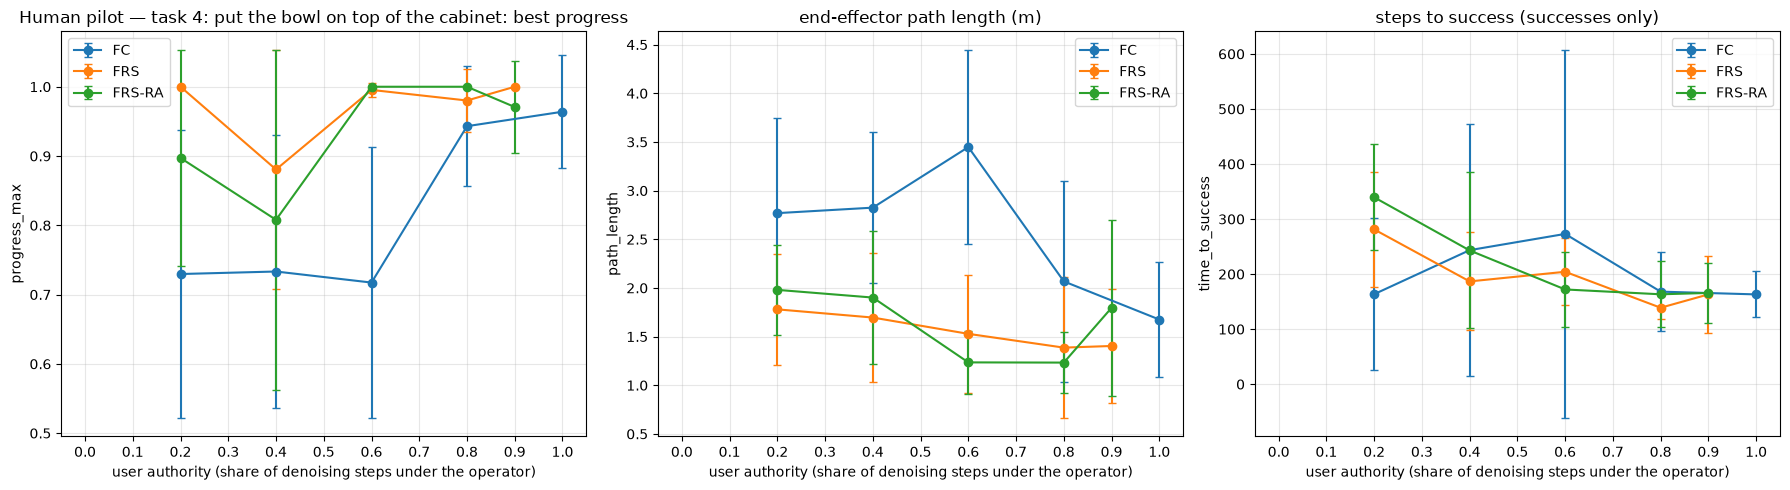

method  authority   n       value    ci95_low   ci95_high
metric                                                                       
progress_max    0       FC        0.2  10    0.729695    0.522408    0.936981
                1       FC        0.4  10    0.733322    0.536977    0.929667
                2       FC        0.6  10    0.717367    0.521772    0.912961
                3       FC        0.8  10    0.943082    0.856492    1.029672
                4       FC        1.0  10    0.963935    0.882351    1.045520
                5      FRS        0.2  10    1.000000         NaN         NaN
                6      FRS        0.4  10    0.880569    0.708340    1.052798
                7      FRS        0.6  10    0.995425    0.985076    1.005774
                8      FRS        0.8  10    0.980134    0.935194    1.025074
                9      FRS        0.9  10    1.000000         NaN         NaN
                10  FRS-RA        0.2  10    0.897216    0.741621    1.052810
                11  FRS-RA        0.4  10    0.807926    0.562453    1.053398
                12  FRS-RA        0.6  10    1.000000         NaN         NaN
                13  FRS-RA        0.8  10    1.000000         NaN         NaN
                14  FRS-RA        0.9  10    0.970740    0.904549    1.036931
path_length     0       FC        0.2  10    2.768869    1.794781    3.742957
                1       FC        0.4  10    2.825165    2.049370    3.600960
                2       FC        0.6  10    3.447745    2.447799    4.447691
                3       FC        0.8  10    2.067526    1.036450    3.098602
                4       FC        1.0  10    1.675429    1.083206    2.267653
                5      FRS        0.2  10    1.780107    1.211654    2.348561
                6      FRS        0.4  10    1.695855    1.035455    2.356254
                7      FRS        0.6  10    1.528438    0.922466    2.134410
                8      FRS        0.8  10    1.386843    0.662845    2.110842
                9      FRS        0.9  10    1.403733    0.822653    1.984814
                10  FRS-RA        0.2  10    1.980246    1.520692    2.439799
                11  FRS-RA        0.4  10    1.901313    1.214394    2.588232
                12  FRS-RA        0.6  10    1.235144    0.911284    1.559004
                13  FRS-RA        0.8  10    1.233034    0.923429    1.542638
                14  FRS-RA        0.9  10    1.796166    0.892036    2.700296
time_to_success 0       FC        0.2   4  163.500000   25.020916  301.979084
                1       FC        0.4   4  243.500000   14.760173  472.239827
                2       FC        0.6   4  273.000000  -61.568306  607.568306
                3       FC        0.8   8  168.125000   96.689138  239.560862
                4       FC        1.0   9  163.111111  121.265546  204.956676
                5      FRS        0.2  10  281.200000  176.887651  385.512349
                6      FRS        0.4   7  186.714286   97.551426  275.877145
                7      FRS        0.6   9  204.222222  143.740235  264.704209
                8      FRS        0.8   9  138.888889  117.956107  159.821670
                9      FRS        0.9  10  163.100000   93.162749  233.037251
                10  FRS-RA        0.2   8  339.500000  243.188980  435.811020
                11  FRS-RA        0.4   7  243.000000  101.296246  384.703754
                12  FRS-RA        0.6  10  172.100000  104.655125  239.544875
                13  FRS-RA        0.8  10  163.300000  103.471704  223.128296
                14  FRS-RA        0.9   9  165.777778  111.289327  220.266228

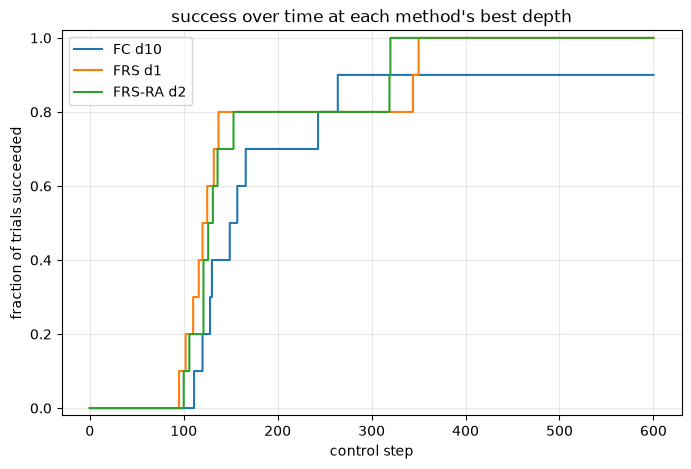

In [5]:
metrics = analyze.trial_metrics(trials)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
tables = [
    analyze.plot_metric(metrics, axes[0], "progress_max"),
    analyze.plot_metric(metrics, axes[1], "path_length"),
    analyze.plot_metric(metrics, axes[2], "time_to_success"),
]
fig.suptitle(f"{title} — per-trial metrics; steps to success over successes only", y=1.02)
fig.tight_layout()
fig.savefig(export / f"trajectory_metrics_vs_authority{suffix}.png", dpi=220, bbox_inches="tight")
summary = pd.concat(tables, keys=["progress_max", "path_length", "time_to_success"], names=["metric"])
summary.to_csv(export / f"trajectory_metrics_vs_authority{suffix}.csv")
plt.show()
display(summary)

at_best = metrics.loc[at_best.index].copy()
at_best["method"] = at_best["method"] + " d" + at_best["depth"].astype(int).astype(str)
fig, ax = plt.subplots(figsize=(7, 4.5))
analyze.plot_success_over_time(at_best, ax, title="Success over time at each method's best depth")
fig.savefig(export / f"success_over_time{suffix}.png", dpi=220, bbox_inches="tight")
plt.show()

## Measured user authority

The x-axis above is the *scheduled* authority — the share of the denoising
schedule the operator constrains, `1 − t*`. This section measures authority from
what actually happened. At every step the recording holds the executed
translation, the operator's command and `policy_translation`, the policy's own
plan for that step (for a steered chunk, the chunk it produced from the same
observation and the same noise without the operator). Per step, user authority
is how far the executed motion moved from the plan toward the command —
`⟨a − p, r − p⟩ / ‖r − p‖²`, clipped to [0, 1] — and policy authority is its
complement (swapping the roles gives exactly `1 −` it). A trial's value is the
mean over its steps; idle steps are 0 by construction.

Left: measured against scheduled authority, one line per method — if the
scheduled axis is a fair comparison the lines coincide. Right: success against
measured authority, each cell at its mean. Runs recorded before
`policy_translation` existed need `replay.py` first.


In [ ]:
if metrics["user_authority"].notna().any():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    measured = analyze.plot_metric(metrics, axes[0], "user_authority")
    axes[0].plot(
        [0, 1], [0, 1], color="#bbbbbb", linewidth=1, linestyle=":", zorder=0
    )  # measured = scheduled
    analyze.plot_metric(metrics, axes[1], "success", x="user_authority")
    fig.tight_layout()
    fig.savefig(export / f"measured_authority{suffix}.png", dpi=220, bbox_inches="tight")
    measured.to_csv(export / f"measured_authority{suffix}.csv", index=False)
    plt.show()
    display(measured)
else:
    print("No policy_translation in these recordings: run replay.py on ROOT first.")

Error bars are descriptive Wilson 95% intervals (t intervals for the continuous metrics). Report participant count, ten attempts per point, all depths, corruption +20°, adaptor translation angle +40°, ten-action chunks, and the common 600-step cap. Human commands receive no synthetic delay. This is an exploratory human pilot, not a confirmed population-level advantage.

The launcher accepts `ORDER`, `FC_DEPTHS` and `FRS_DEPTHS` to vary method/depth order across participants; account for practice and fatigue. `on_target` needs target annotations or ceiling anchors, which this pilot does not collect.
